In [1]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [2]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from torchvision.transforms import v2
from torchvision.io import decode_image
from torch.utils.data import Dataset
import os
import zipfile

In [3]:
import zipfile
with zipfile.ZipFile("/content/drive/MyDrive/hanyang/SIR2.zip") as z:
    z.extractall("/content/data/SIR2")


In [ ]:

for f in os.listdir("/content/data/SIR2"):
    p = os.path.join("/content/data/SIR2", f)
    if os.path.isdir(p):
        print(f"[DIR]  {f}")
    else:
        print(f"[FILE] {f}  ({os.path.getsize(p)/1e6:.1f} Mo)")

[FILE] SolidObjectDataset.zip  (13.8 Mo)
[FILE] Postcard Dataset.zip  (177.7 Mo)
[FILE] Wildscene.zip  (5.9 Mo)


In [5]:
base = "/content/data/SIR2"
inner = ["SolidObjectDataset.zip", "Postcard Dataset.zip", "Wildscene.zip"]

for z in inner:
    with zipfile.ZipFile(os.path.join(base, z)) as zf:
        names = zf.namelist()
        print(f"\n=== {z} : {len(names)} entrées ===")
        for n in names[:25]:
            print("  ", n)


=== SolidObjectDataset.zip : 862 entrées ===
   SolidObjectDataset/
   SolidObjectDataset/1/
   SolidObjectDataset/1/Focus/
   SolidObjectDataset/1/Focus/11/
   SolidObjectDataset/1/Focus/11/g.jpg
   SolidObjectDataset/1/Focus/11/m.jpg
   SolidObjectDataset/1/Focus/11/r.jpg
   SolidObjectDataset/1/Focus/13/
   SolidObjectDataset/1/Focus/13/g.jpg
   SolidObjectDataset/1/Focus/13/m.jpg
   SolidObjectDataset/1/Focus/13/r.jpg
   SolidObjectDataset/1/Focus/16/
   SolidObjectDataset/1/Focus/16/g.jpg
   SolidObjectDataset/1/Focus/16/m.jpg
   SolidObjectDataset/1/Focus/16/r.jpg
   SolidObjectDataset/1/Focus/19/
   SolidObjectDataset/1/Focus/19/g.jpg
   SolidObjectDataset/1/Focus/19/m.jpg
   SolidObjectDataset/1/Focus/19/r.jpg
   SolidObjectDataset/1/Focus/22/
   SolidObjectDataset/1/Focus/22/g.jpg
   SolidObjectDataset/1/Focus/22/m.jpg
   SolidObjectDataset/1/Focus/22/r.jpg
   SolidObjectDataset/1/Focus/27/
   SolidObjectDataset/1/Focus/27/g.jpg

=== Postcard Dataset.zip : 840 entrées ===
   

In [6]:
base = "/content/data/SIR2"
inner = {
    "SolidObjectDataset.zip": "SolidObject",
    "Postcard Dataset.zip": "Postcard",
    "Wildscene.zip": "Wild",
}
for z, out in inner.items():
    with zipfile.ZipFile(os.path.join(base, z)) as zf:
        zf.extractall(os.path.join(base, out))
    print(f"{z} → {out}/ OK")

SolidObjectDataset.zip → SolidObject/ OK
Postcard Dataset.zip → Postcard/ OK
Wildscene.zip → Wild/ OK


In [7]:
for dirpath, dirnames, filenames in os.walk(base):
    if len(filenames)>=3:
        print(filenames)

['SolidObjectDataset.zip', 'Postcard Dataset.zip', 'Wildscene.zip']
['m.jpg', 'r.jpg', 'g.jpg']
['m.jpg', 'r.jpg', 'g.jpg']
['m.jpg', 'r.jpg', 'g.jpg']
['m.jpg', 'r.jpg', 'g.jpg']
['m.jpg', 'r.jpg', 'g.jpg']
['m.jpg', 'r.jpg', 'g.jpg']
['m.jpg', 'r.jpg', 'g.jpg']
['m.jpg', 'r.jpg', 'g.jpg']
['m.jpg', 'r.jpg', 'g.jpg']
['m.jpg', 'r.jpg', 'g.jpg']
['m.jpg', 'r.jpg', 'g.jpg']
['m.jpg', 'r.jpg', 'g.jpg']
['m.jpg', 'r.jpg', 'g.jpg']
['m.jpg', 'r.jpg', 'g.jpg']
['m.jpg', 'r.jpg', 'g.jpg']
['m.jpg', 'r.jpg', 'g.jpg']
['m.jpg', 'r.jpg', 'g.jpg']
['m.jpg', 'r.jpg', 'g.jpg']
['m.jpg', 'r.jpg', 'g.jpg']
['m.jpg', 'r.jpg', 'g.jpg']
['m.jpg', 'r.jpg', 'g.jpg']
['m.jpg', 'r.jpg', 'g.jpg']
['m.jpg', 'r.jpg', 'g.jpg']
['m.jpg', 'r.jpg', 'g.jpg']
['m.jpg', 'r.jpg', 'g.jpg']
['m.jpg', 'r.jpg', 'g.jpg']
['m.jpg', 'r.jpg', 'g.jpg']
['m.jpg', 'r.jpg', 'g.jpg']
['m.jpg', 'r.jpg', 'g.jpg']
['m.jpg', 'r.jpg', 'g.jpg']
['m.jpg', 'r.jpg', 'g.jpg']
['m.jpg', 'r.jpg', 'g.jpg']
['m.jpg', 'r.jpg', 'g.jpg']
['m.jpg'

In [ ]:
def det_role(str):
    if "r." in str or "-r" in str:
        return "r"
    elif "m." in str or "-m" in str :
        return "m"
    else:
        return "g"

def build_index(subset_root):
    """
    input: str
    output: list[dict]
    """
    dico = []
    for dirpath, dirnames, filenames in os.walk(subset_root):
        if len(filenames)==3:
            if "jpg" in filenames[0][-3:] or "png" in filenames[0][-3]:
                dico.append({det_role(i): os.path.join(dirpath, i) for i in filenames})

    return dico


index = build_index(base)
print(index[15])


{'m': '/content/data/SIR2/SolidObject/SolidObjectDataset/14/Focus/22/m.jpg', 'r': '/content/data/SIR2/SolidObject/SolidObjectDataset/14/Focus/22/r.jpg', 'g': '/content/data/SIR2/SolidObject/SolidObjectDataset/14/Focus/22/g.jpg'}


In [9]:
import random
n  = random.randint(0, len(index)-1)
dic_i = index[n]
r, m, g = decode_image(dic_i["r"]), decode_image(dic_i['m']), decode_image(dic_i['g'])
print(r.shape)

torch.Size([3, 400, 540])


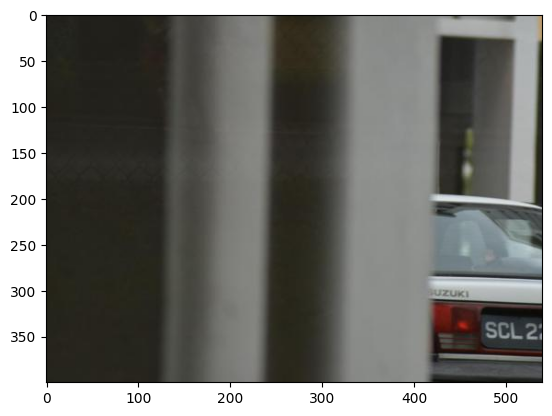

In [10]:
y = m.detach().float().cpu()
y = y.permute(1,2,0).numpy().astype(np.uint8)
plt.imshow(y)
plt.show()

In [11]:
index[:50]

[{'m': '/content/data/SIR2/SolidObject/SolidObjectDataset/3/Thick/3/m.jpg',
  'r': '/content/data/SIR2/SolidObject/SolidObjectDataset/3/Thick/3/r.jpg',
  'g': '/content/data/SIR2/SolidObject/SolidObjectDataset/3/Thick/3/g.jpg'},
 {'m': '/content/data/SIR2/SolidObject/SolidObjectDataset/3/Thick/5/m.jpg',
  'r': '/content/data/SIR2/SolidObject/SolidObjectDataset/3/Thick/5/r.jpg',
  'g': '/content/data/SIR2/SolidObject/SolidObjectDataset/3/Thick/5/g.jpg'},
 {'m': '/content/data/SIR2/SolidObject/SolidObjectDataset/3/Thick/10/m.jpg',
  'r': '/content/data/SIR2/SolidObject/SolidObjectDataset/3/Thick/10/r.jpg',
  'g': '/content/data/SIR2/SolidObject/SolidObjectDataset/3/Thick/10/g.jpg'},
 {'m': '/content/data/SIR2/SolidObject/SolidObjectDataset/3/Focus/27/m.jpg',
  'r': '/content/data/SIR2/SolidObject/SolidObjectDataset/3/Focus/27/r.jpg',
  'g': '/content/data/SIR2/SolidObject/SolidObjectDataset/3/Focus/27/g.jpg'},
 {'m': '/content/data/SIR2/SolidObject/SolidObjectDataset/3/Focus/32/m.jpg',
 

In [ ]:
class SirDataset(Dataset):
    """
    Dataset SIR
    """
    def __init__(self, base):
        self.index = build_index(base)
        self.crop = v2.CenterCrop((400, 536))

    def __len__(self):
        return len(self.index)
    def __getitem__(self, i):
        dic_i = self.index[i]
        r, m, g = decode_image(dic_i["r"]), decode_image(dic_i['m']), decode_image(dic_i['g'])
        return [self.crop(r), self.crop(m), self.crop(g)]

torch.uint8 2 233


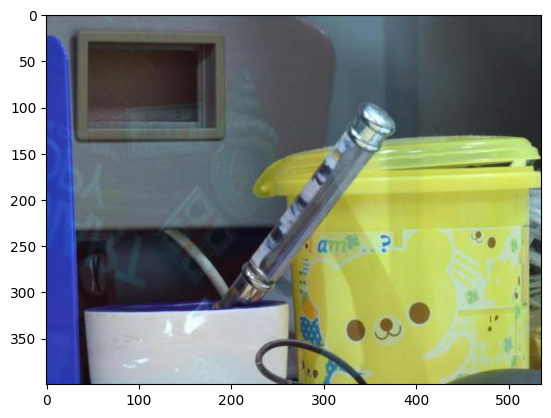

In [13]:
ds = SirDataset(base)
ds[15][0].shape
y2 = ds[40][1]
print(y2.dtype, y.min(), y.max())
y = y2.detach().float().cpu()
y = y.permute(1,2,0).numpy().astype(np.uint8)
plt.imshow(y)
plt.show()

In [14]:
transforms = v2.Compose([
    v2.ToDtype(torch.float32, scale=True),
    v2.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]),

])
z = transforms(y2)

In [15]:
# from diffusers import Flux2KleinPipeline, AutoencoderKLFlux2

In [16]:
from diffusers import AutoencoderKL
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

vae = AutoencoderKL.from_pretrained(
    "black-forest-labs/FLUX.2-klein-4B",
    subfolder="vae",
    torch_dtype=torch.bfloat16
).to(device)

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_validators.py:205: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `hf_hub_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:138: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_h

config.json:   0%|          | 0.00/821 [00:00<?, ?B/s]

vae/diffusion_pytorch_model.safetensors:   0%|          | 0.00/168M [00:00<?, ?B/s]

Some weights of the model checkpoint at black-forest-labs/FLUX.2-klein-4B were not used when initializing AutoencoderKL: 
 ['bn.num_batches_tracked, bn.running_var, bn.running_mean']


In [18]:
ds[2][0].dtype

torch.uint8

In [ ]:
def cosine(a,b):
    """
    input: torch.tensor, torch.tensor
    output: float
    """
    a = a.flatten()
    b = b.flatten()
    return torch.dot(a,b)/(torch.norm(a)*torch.norm(b))
cosine_pix = []
cosine_lat = []
cosine_after = []
for i in range(300):
    a, b = transforms(ds[i][0]), transforms(ds[i][2])
    cosine_pix.append(cosine(a, b))
    a, b = a[None, :, :, :], b[None, :, :, :]                         
    a, b = a.to(device, dtype=torch.bfloat16), b.to(device, dtype=torch.bfloat16)

    with torch.no_grad():
        a = vae.encode(a).latent_dist.sample()
        b = vae.encode(b).latent_dist.sample()
        c = vae.decode(a).sample 
        d = vae.decode(b).sample 
    cosine_lat.append(cosine(a, b))
    cosine_after.append(cosine(c, d))



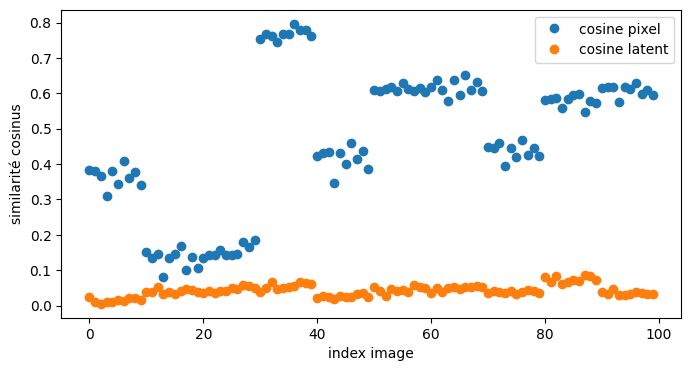

In [ ]:
pix = np.array([abs(c.item()) for c in cosine_pix])
lat = np.array([abs(c.item()) for c in cosine_lat])
aft = np.array([abs(c.item) for c in cosine_after])
plt.figure(figsize=(8,4))
plt.plot(pix, "o", ms=2, label="cosine pixel")
plt.plot(lat, "o", ms=2, label="cosine latent")
plt.plot(aft, "o", ms=2, label="cosine pix-decoded")
plt.xlabel("index image")
plt.ylabel("similarité cosinus")
plt.legend()
plt.show()


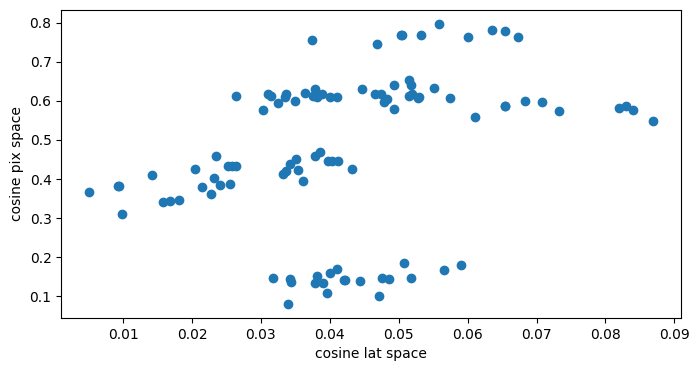

In [ ]:
plt.figure(figsize=(8,4))
plt.plot(lat, pix, "o", ms=2)
plt.xlabel('cosine lat space')
plt.ylabel("cosine pix space")
plt.show()